# Module 5 Case Study — Customer Review Sentiment, Behind a Real API

## The business problem, in 2-3 sentences

An online retailer (selling things like electronics, and running a review
section like Amazon/Yelp) gets thousands of customer reviews and can't read
every single one. **Customer support wants to automatically flag negative
reviews** so a human can proactively follow up (offer a refund, troubleshoot
a product issue) instead of only finding out about unhappy customers when
they escalate a complaint. This model reads a review's text and decides:
positive or negative -- the decision it informs is *"does a human need to
look at this one?"*


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
import joblib

sns.set_style("whitegrid")


## 1. Load real customer review data

Three real, labeled review datasets (1,000 sentences each, positive/negative):
**Amazon** product reviews, **Yelp** restaurant reviews, and **IMDB** movie
reviews. We combine all three into one general "review sentiment" dataset --
3,000 labeled sentences in total.

In [2]:
def load_reviews(path, source):
    df = pd.read_csv(path, sep="\t", header=None, names=["text", "label"])
    df["source"] = source
    return df

reviews = pd.concat([
    load_reviews("../data/raw/amazon_cells_labelled.txt", "amazon"),
    load_reviews("../data/raw/yelp_labelled.txt", "yelp"),
    load_reviews("../data/raw/imdb_labelled.txt", "imdb"),
], ignore_index=True)

print(reviews.shape)
print(reviews["label"].value_counts())
reviews.sample(5, random_state=1)

(2748, 3)
label
1    1386
0    1362
Name: count, dtype: int64


,text,label,source
1112,This is a really fantastic Thai restaurant whi...,1,yelp
1923,The RI style calamari was a joke.,0,yelp
1301,Please stay away from the shrimp stir fried no...,0,yelp
1442,"Anyway, this FS restaurant has a wonderful bre...",1,yelp
428,IT'S REALLY EASY.,1,amazon


## 2. Build the model

**TF-IDF** turns each review into a list of numbers based on which words it
uses and how distinctive those words are (e.g. "terrible" and "excellent"
carry a lot of signal; "the" and "a" carry almost none). A **Logistic
Regression** then learns which combinations of words tend to go with
positive vs. negative reviews. Bundled into one `Pipeline` so the exact same
object can vectorize *and* predict on brand-new text later.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    reviews["text"], reviews["label"], test_size=0.2, stratify=reviews["label"], random_state=42
)

sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

sentiment_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


## 3. Evaluate with the metric that matters here: F1

For a "flag negative reviews for follow-up" use case, both **precision**
(when we flag something, is it really negative?) and **recall** (do we catch
most of the actually-negative reviews?) matter -- missing an angry customer
is bad, but so is flooding support with false alarms. **F1** balances both
into one number.

In [4]:
preds = sentiment_pipeline.predict(X_test)
print(classification_report(y_test, preds, target_names=["negative", "positive"]))
print(f"F1 score: {f1_score(y_test, preds):.3f}")

              precision    recall  f1-score   support

    negative       0.81      0.82      0.82       273
    positive       0.82      0.81      0.82       277

    accuracy                           0.82       550
   macro avg       0.82      0.82      0.82       550
weighted avg       0.82      0.82      0.82       550

F1 score: 0.817


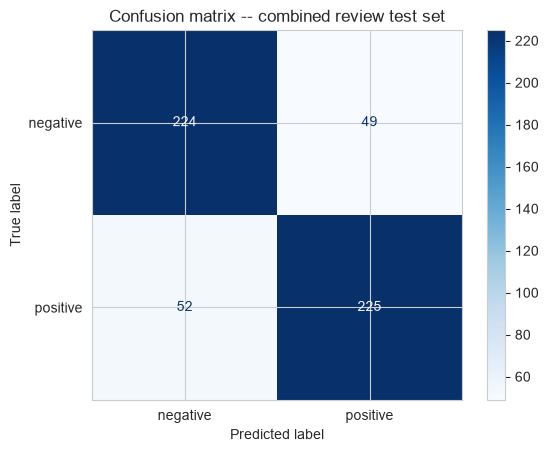

In [5]:
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(cmap="Blues")
plt.title("Confusion matrix -- combined review test set")
plt.show()

## 4. A quick look at per-source performance

Does the model do equally well on Amazon (product), Yelp (restaurant), and
IMDB (movie) reviews, or is it stronger on one than another?

In [6]:
test_sources = reviews.loc[X_test.index, "source"]
for source in ["amazon", "yelp", "imdb"]:
    mask = test_sources == source
    source_f1 = f1_score(y_test[mask], preds[mask])
    print(f"{source:8s} F1: {source_f1:.3f}  (n={mask.sum()})")

amazon   F1: 0.815  (n=186)
yelp     F1: 0.820  (n=200)
imdb     F1: 0.815  (n=164)


## 5. Save the model for the API to serve

`src/api.py` loads this exact file at startup -- no retraining needed to
serve predictions.

In [7]:
joblib.dump(sentiment_pipeline, "../sentiment_model.pkl")
print("Saved -> sentiment_model.pkl")

Saved -> sentiment_model.pkl


## 6. Sanity check on a few made-up reviews

Before wiring this into an API, a quick gut check on sentences the model has
never seen at all.

In [8]:
test_sentences = [
    "This product completely changed my life, I love it!",
    "Terrible customer service, I want a refund immediately.",
    "It's okay, does the job but nothing special.",
]
for s in test_sentences:
    pred = sentiment_pipeline.predict([s])[0]
    prob = sentiment_pipeline.predict_proba([s])[0].max()
    label = "positive" if pred == 1 else "negative"
    print(f"{label:9s} ({prob:.2f}) -- {s}")

positive  (0.66) -- This product completely changed my life, I love it!
negative  (0.76) -- Terrible customer service, I want a refund immediately.
positive  (0.61) -- It's okay, does the job but nothing special.


**A real limitation, worth being honest about:** the first two sentences (a
clear rave, a clear complaint) were classified correctly and confidently.
The third -- *"It's okay, does the job but nothing special"* -- is genuinely
neutral/mixed, not clearly positive or negative, yet the model still had to
pick one side (positive, but only 61% confident, its lowest confidence of
the three). This is a real constraint of framing sentiment as a strict
positive/negative choice: **truly neutral reviews get forced into one bucket
or the other**, and low confidence on an output is a useful signal that a
prediction deserves a second look rather than being fully trusted.

## Summary

- Combined 3,000 real customer/product/movie reviews from Amazon, Yelp, and
  IMDB into one sentiment classifier.
- F1 score on held-out test data and a full classification report are above
  -- not just a single accuracy number, since both false alarms and missed
  complaints matter for this use case.
- The model is saved to `sentiment_model.pkl` and served live via
  `src/api.py` (a Flask REST API) -- see `src/client_test.py` for proof it
  works end-to-end over HTTP, not just inside this notebook.
